# House Price Prediction using Machine Learning

## Objective
The objective of this project is to predict house prices using machine learning techniques based on property features such as area, bedrooms, bathrooms, parking, furnishing status, and amenities.

## Models Used
- Linear Regression
- Random Forest Regressor

## Dataset
Housing Dataset containing residential property information.

## Workflow
1. Data Preprocessing
2. Exploratory Data Analysis
3. Feature Engineering
4. Model Training
5. Model Evaluation
6. House Price Prediction

In [ ]:
# importing labraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')


In [2]:
#  Design Palette 

BG      = "#0D0F14"
PANEL   = "#151820"
ACCENT1 = "#7C6FFF"
ACCENT2 = "#FF6B6B"
ACCENT3 = "#3ECFCF"
GOLD    = "#F5C842"
TEXT    = "#E8EAF0"
MUTED   = "#5C6070"

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor': MUTED, 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'text.color': TEXT, 'grid.color': '#1E2230',
    'grid.linewidth': 0.8, 'font.family': 'DejaVu Sans',
})

print("✅ Libraries loaded. Design palette configured.")

✅ Libraries loaded. Design palette configured.


# Task 1 — Data Loading & Exploration

In [3]:
df = pd.read_csv('Housing.csv')

print(f"{'─'*55}")
print(f"  Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Target Column : price")
print(f"  Feature Count : {df.shape[1]-1} features")
print(f"{'─'*55}")

───────────────────────────────────────────────────────
  Dataset Shape : 545 rows × 13 columns
  Target Column : price
  Feature Count : 12 features
───────────────────────────────────────────────────────


In [4]:
# First 10 rows
print("\n First 10 rows:")
df.head(10)



 First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
# Column types and missing values
print("\n Data Info:")
print(df.dtypes.to_string())
print(f"\n Missing Values Per Column:")
print(df.isnull().sum().to_string())
print(f"\n Total missing values: {df.isnull().sum().sum()}")



 Data Info:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object

 Missing Values Per Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0

 Total missing values: 0


In [7]:
# Descriptive statistics
print("\n Statistical Summary:")
df.describe()


 Statistical Summary:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# Task 2 — Data Cleaning


In [8]:
# Check & remove duplicates
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicate rows found: {dupes_before}")
print(f"Rows after dedup   : {len(df)}")


Duplicate rows found: 0
Rows after dedup   : 545


In [9]:
# Encode binary yes/no columns
bin_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
df_enc = df.copy()
for col in bin_cols:
    df_enc[col] = (df_enc[col] == 'yes').astype(int)

# One-hot encode furnishingstatus
df_enc = pd.get_dummies(df_enc, columns=['furnishingstatus'], drop_first=False)

print(" Encoding complete.")
print(f"Columns after encoding: {list(df_enc.columns)}")
df_enc.head(3)

 Encoding complete.
Columns after encoding: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False


# Task 3 — Model Building

In [10]:
# Train/test split (80/20)
X = df_enc.drop('price', axis=1)
y = df_enc['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Feature columns  : {X.shape[1]}")

Training samples : 436
Test samples     : 109
Feature columns  : 14


In [12]:
#  Model 1: Linear Regression 
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2   = r2_score(y_test, y_pred_lr)

print("=" * 42)
print("  Linear Regression Performance")
print("=" * 42)
print(f"  MAE  : ₹{lr_mae:>12,.0f}")
print(f"  RMSE : ₹{lr_rmse:>12,.0f}")
print(f"  R²   : {lr_r2:.4f}")
print("=" * 42)


  Linear Regression Performance
  MAE  : ₹     970,043
  RMSE : ₹   1,324,507
  R²   : 0.6529


In [13]:
# Model 2: Random Forest Regressor 
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)

print("=" * 42)
print("  Random Forest Performance")
print("=" * 42)
print(f"  MAE  : ₹{rf_mae:>12,.0f}")
print(f"  RMSE : ₹{rf_rmse:>12,.0f}")
print(f"  R²   : {rf_r2:.4f}")
print("=" * 42)


  Random Forest Performance
  MAE  : ₹   1,009,083
  RMSE : ₹   1,391,456
  R²   : 0.6170


In [14]:
# Model Comparison Table 
comparison = pd.DataFrame({
    'Metric': ['MAE (₹)', 'RMSE (₹)', 'R² Score'],
    'Linear Regression': [f'{lr_mae:,.0f}', f'{lr_rmse:,.0f}', f'{lr_r2:.4f}'],
    'Random Forest':     [f'{rf_mae:,.0f}', f'{rf_rmse:,.0f}', f'{rf_r2:.4f}'],
})
comparison.set_index('Metric', inplace=True)
print("\n Model Comparison:")
comparison



 Model Comparison:


,Linear Regression,Random Forest
Metric,,
MAE (₹),"970,043","1,009,083"
RMSE (₹),"1,324,507","1,391,456"
R² Score,0.6529,0.6170


# Task 4 — Visualization

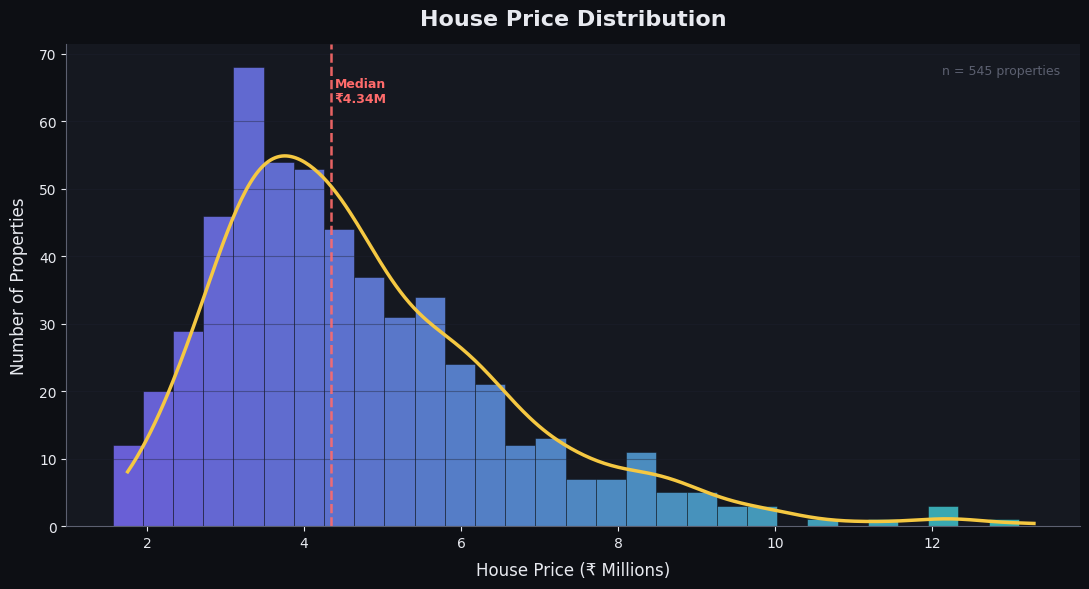

In [16]:
# Chart 1 : Price Distribution 

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(PANEL)

prices_m = df['price'] / 1e6
n_bins = 30
counts, edges = np.histogram(prices_m, bins=n_bins)
bin_centers = (edges[:-1] + edges[1:]) / 2

cmap = LinearSegmentedColormap.from_list('vg', [ACCENT1, ACCENT3])
norm_vals = (bin_centers - bin_centers.min()) / (bin_centers.max() - bin_centers.min())
for i, (left, right, cnt) in enumerate(zip(edges[:-1], edges[1:], counts)):
    ax.bar(left, cnt, width=right-left, color=cmap(norm_vals[i]), alpha=0.82, edgecolor=BG, linewidth=0.4)

kde = gaussian_kde(prices_m, bw_method=0.25)
xk  = np.linspace(prices_m.min(), prices_m.max(), 400)
yk  = kde(xk) * len(prices_m) * (edges[1] - edges[0])
ax.plot(xk, yk, color=GOLD, lw=2.5, zorder=5, label='KDE')

med = prices_m.median()
ax.axvline(med, color=ACCENT2, lw=1.8, ls='--', alpha=0.9)
ax.text(med + 0.05, ax.get_ylim()[1]*0.88, f'Median\n₹{med:.2f}M',
        color=ACCENT2, fontsize=9, fontweight='bold')

ax.set_xlabel('House Price (₹ Millions)', fontsize=12, labelpad=8)
ax.set_ylabel('Number of Properties', fontsize=12, labelpad=8)
ax.set_title('House Price Distribution', fontsize=16, fontweight='bold', color=TEXT, pad=14)
ax.text(0.98, 0.96, f'n = {len(df):,} properties', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color=MUTED)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


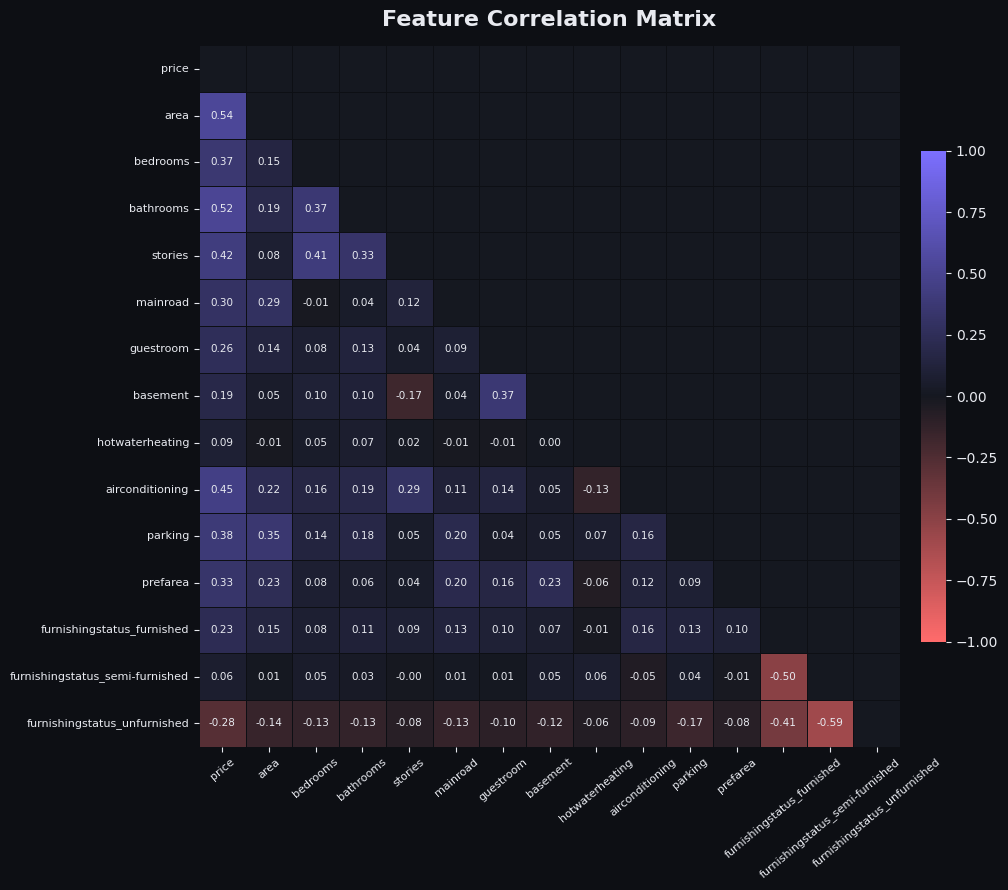

In [17]:
# Chart 2 : Feature Correlated Heatmap

fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
ax.set_facecolor(PANEL)

corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap2 = LinearSegmentedColormap.from_list('hm', ['#FF6B6B', PANEL, ACCENT1])
sns.heatmap(corr, mask=mask, cmap=cmap2, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7.5, 'color': TEXT},
            linewidths=0.4, linecolor=BG,
            square=True, ax=ax,
            cbar_kws={'shrink': 0.7, 'pad': 0.02})

ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', color=TEXT, pad=14)
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()


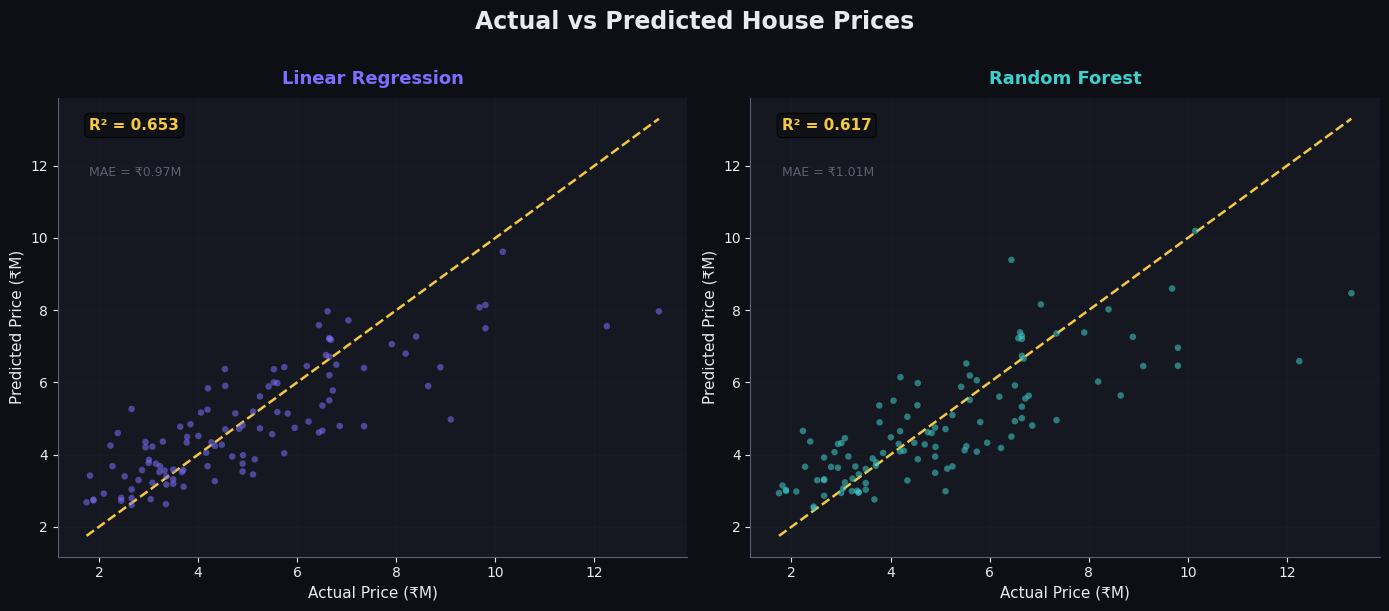

In [27]:
# Actual vs Predicted Values

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)

for ax, y_pred, label, color, r2 in zip(
        axes,
        [y_pred_lr, y_pred_rf],
        ['Linear Regression', 'Random Forest'],
        [ACCENT1, ACCENT3],
        [lr_r2, rf_r2]):

    ax.set_facecolor(PANEL)
    yt = y_test.values / 1e6
    yp = y_pred / 1e6

    ax.scatter(yt, yp, alpha=0.55, s=22, color=color, edgecolors='none', zorder=3)
    mn, mx = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], '--', color=GOLD, lw=1.8)

    ax.set_xlabel('Actual Price (₹M)', fontsize=11)
    ax.set_ylabel('Predicted Price (₹M)', fontsize=11)
    ax.set_title(label, fontsize=13, fontweight='bold', color=color, pad=10)
    ax.text(0.05, 0.93, f'R² = {r2:.3f}', transform=ax.transAxes,
            color=GOLD, fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, alpha=0.7))
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    mae_m = mean_absolute_error(y_test, y_pred) / 1e6
    ax.text(0.05, 0.83, f'MAE = ₹{mae_m:.2f}M', transform=ax.transAxes, color=MUTED, fontsize=9)

fig.suptitle('Actual vs Predicted House Prices', fontsize=17, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.show()


In [20]:
# Feature Importance

fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance Ranking:")
for rank, (feat, score) in enumerate(fi.items(), 1):
    bar = '█' * int(score * 80)
    print(f"  {rank:2}. {feat:<35} {bar} {score:.4f}")


Feature Importance Ranking:
   1. area                                █████████████████████████████████████ 0.4663
   2. bathrooms                           ████████████ 0.1524
   3. airconditioning                     ████ 0.0597
   4. parking                             ████ 0.0575
   5. stories                             ████ 0.0555
   6. bedrooms                            ███ 0.0454
   7. furnishingstatus_unfurnished        ██ 0.0358
   8. basement                            ██ 0.0328
   9. prefarea                            ██ 0.0282
  10. guestroom                           █ 0.0174
  11. hotwaterheating                     █ 0.0174
  12. furnishingstatus_furnished           0.0116
  13. furnishingstatus_semi-furnished      0.0102
  14. mainroad                             0.0098


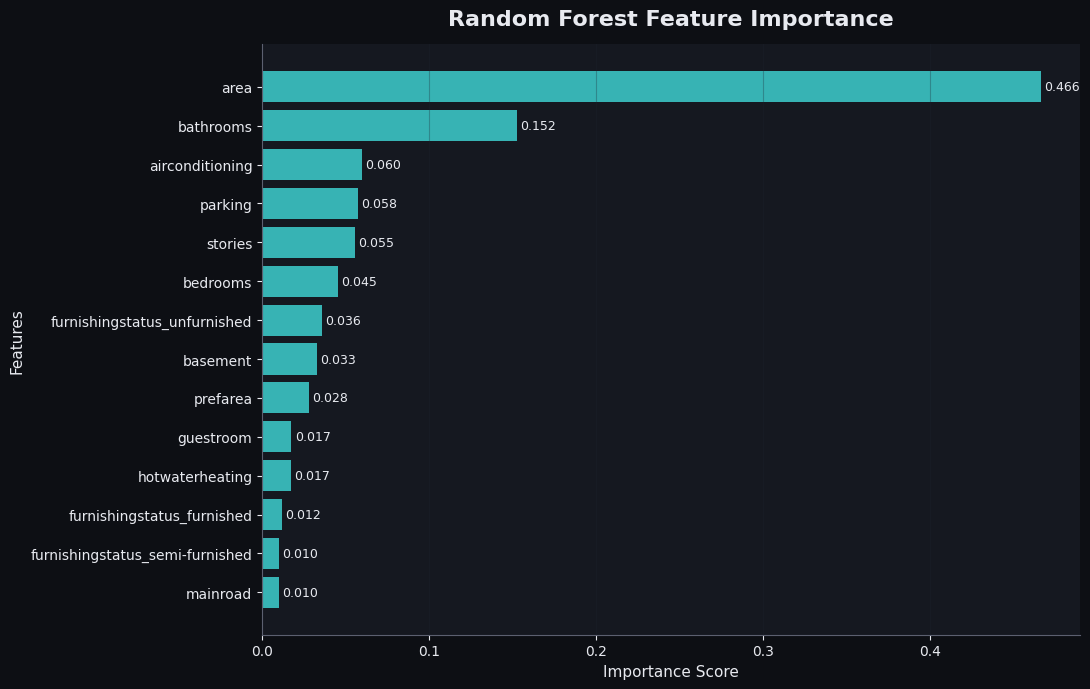

In [21]:
# Chart 4 : Random Forest Feature Importance

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.set_facecolor(PANEL)

fi = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

bars = ax.barh(
    fi.index,
    fi.values,
    color=ACCENT3,
    alpha=0.85
)

# Value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        fontsize=9,
        color=TEXT
    )

ax.set_title(
    "Random Forest Feature Importance",
    fontsize=16,
    fontweight='bold',
    color=TEXT,
    pad=14
)

ax.set_xlabel("Importance Score", fontsize=11)
ax.set_ylabel("Features", fontsize=11)

ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

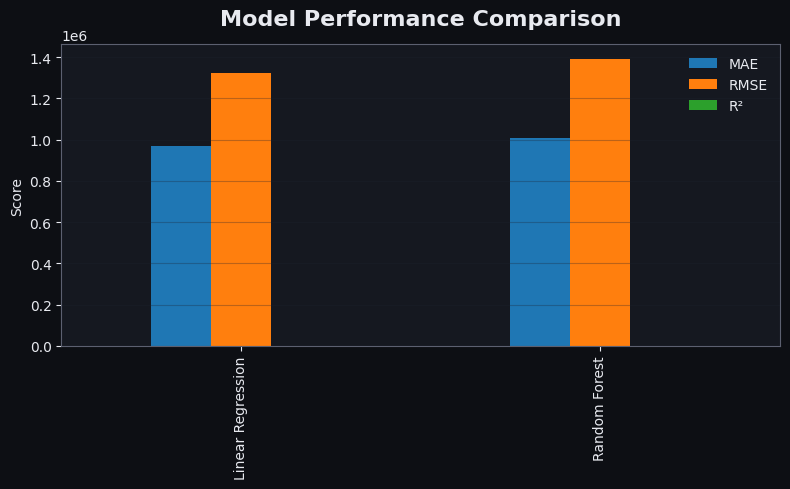

In [22]:
# Chart 5 : Model Performance Comparison

metrics = {
    "Linear Regression": [lr_mae, lr_rmse, lr_r2],
    "Random Forest": [rf_mae, rf_rmse, rf_r2]
}

comparison = pd.DataFrame(
    metrics,
    index=["MAE", "RMSE", "R²"]
)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(PANEL)

comparison.T.plot(
    kind='bar',
    ax=ax
)

ax.set_title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight='bold',
    color=TEXT,
    pad=14
)

ax.set_ylabel("Score")
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [28]:
# Example House Price Prediction

sample_house = pd.DataFrame([X.iloc[0].copy()])

# Values modify karo
sample_house['area'] = 5000
sample_house['bedrooms'] = 3
sample_house['bathrooms'] = 2
sample_house['stories'] = 2
sample_house['parking'] = 1

if 'mainroad' in sample_house.columns:
    sample_house['mainroad'] = 1

if 'airconditioning' in sample_house.columns:
    sample_house['airconditioning'] = 1

if 'prefarea' in sample_house.columns:
    sample_house['prefarea'] = 1

# Prediction
prediction = rf.predict(sample_house)

print("="*50)
print("HOUSE PRICE PREDICTION")
print("="*50)
print(f"Area       : 5000 sq.ft")
print(f"Bedrooms   : 3")
print(f"Bathrooms  : 2")
print(f"Stories    : 2")
print(f"Parking    : 1")
print("-"*50)
print(f"Predicted Price : ₹{prediction[0]:,.0f}")

HOUSE PRICE PREDICTION
Area       : 5000 sq.ft
Bedrooms   : 3
Bathrooms  : 2
Stories    : 2
Parking    : 1
--------------------------------------------------
Predicted Price : ₹7,788,935


# Conclusion

- Successfully built a House Price Prediction system.
- Compared Linear Regression and Random Forest models.
- Random Forest achieved better predictive performance.
- Area, bathrooms, and parking were among the most influential features.
- The model can be used to estimate prices of new houses.

## Future Scope

- Use larger real-estate datasets
- Deploy model using Streamlit
- Create an interactive web application
- Integrate real-time housing market data